In [1]:
import sys
import utils as utils
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
reload(utils)
from tqdm import tqdm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (8, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)
%config InlineBackend.figure_format = "retina"

import matplotlib
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
dpi = 300

## Load parameters

In [17]:
params_env = {
'sigma' : 1,
'S0' : 100., 
'Z0' : 100., 
'Y0' : 1000., 
'eta' : 0.2, 
'xi' : 1., 
'T' : 1., 
'a1' : 1, 
'a2' : 1, 
'Nt' : 1_000, 
'r' : 0.5
}

## Define environment

In [18]:
env = utils.environment(**params_env)

In [19]:
fs = 14
fsL = 19
plt.rcParams["font.size"] = fs

In [20]:
vs = env.solve_v123456()

In [21]:
vs.shape

(6, 1001)

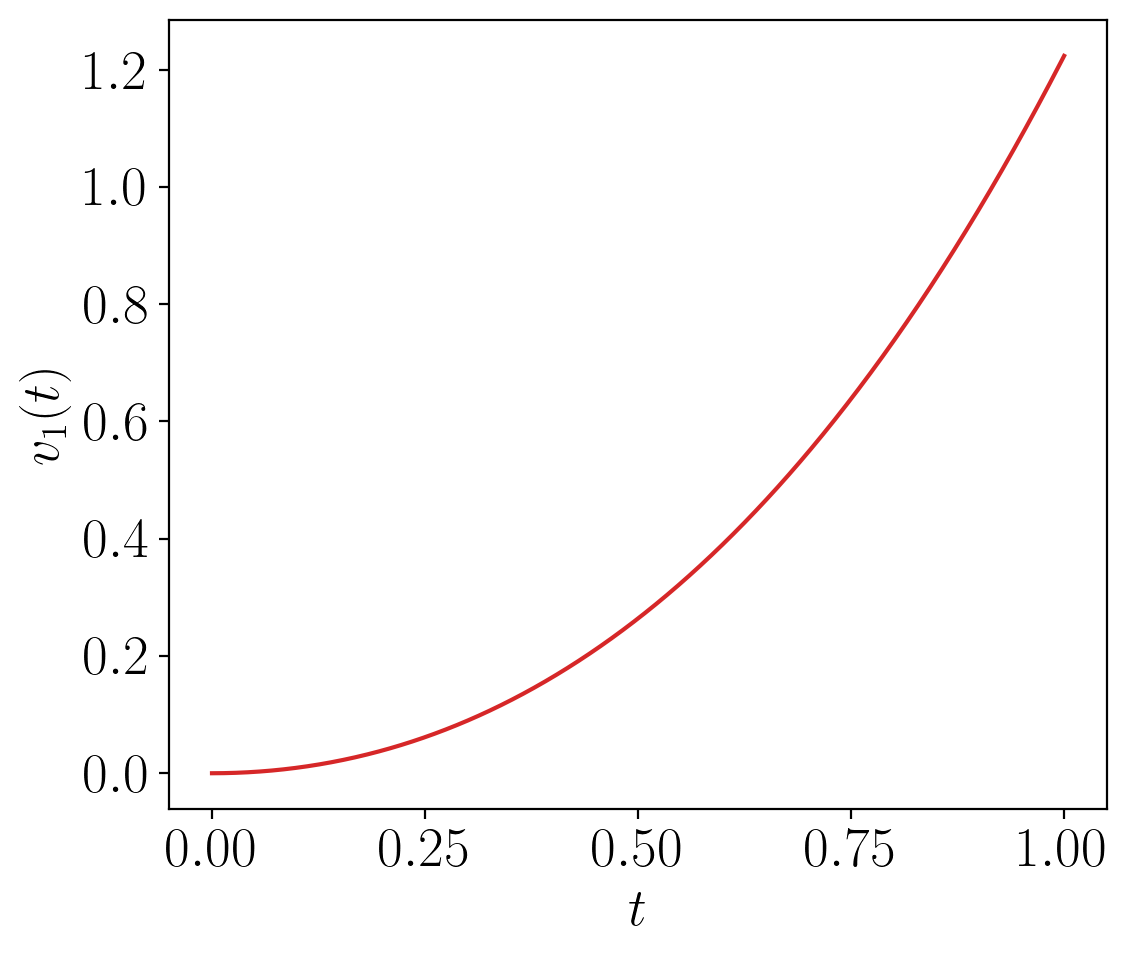

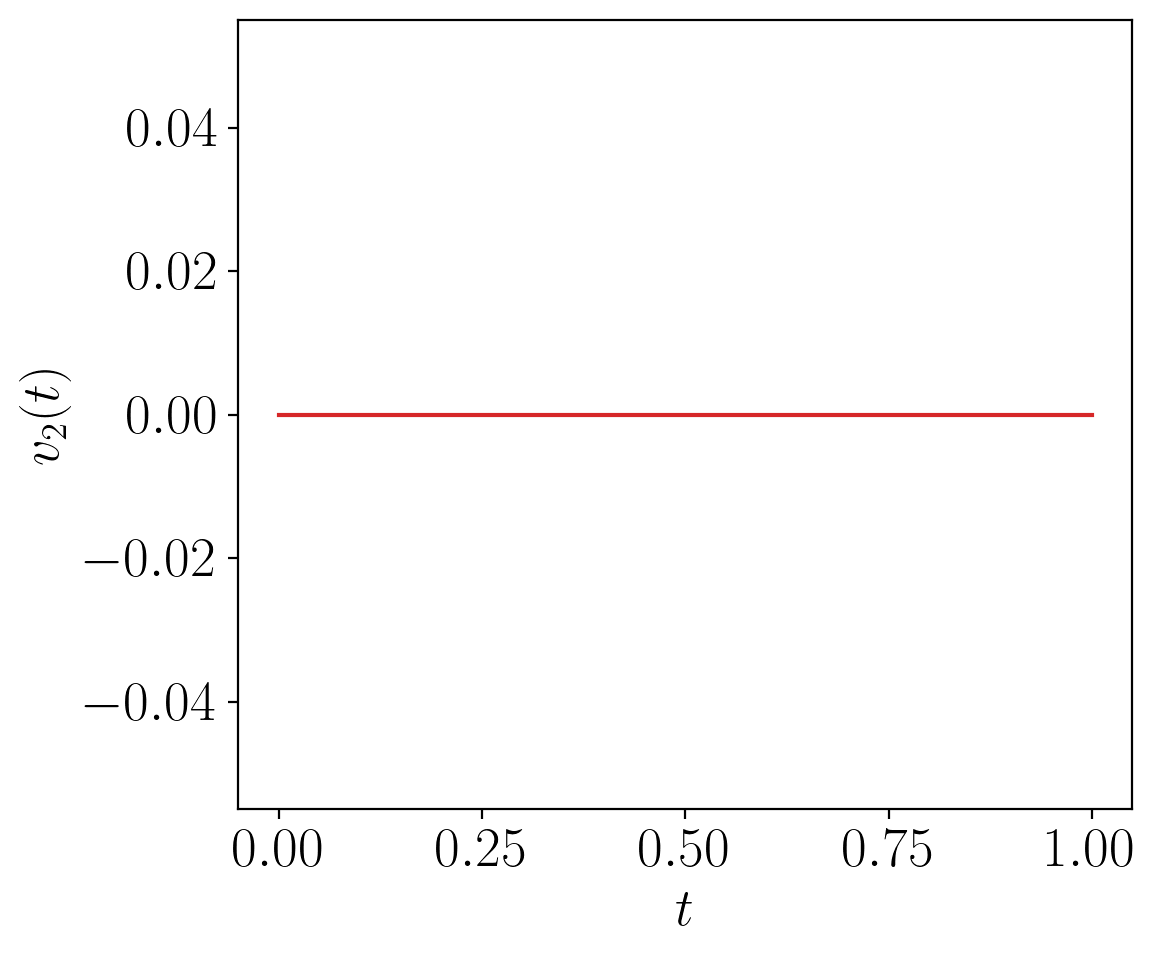

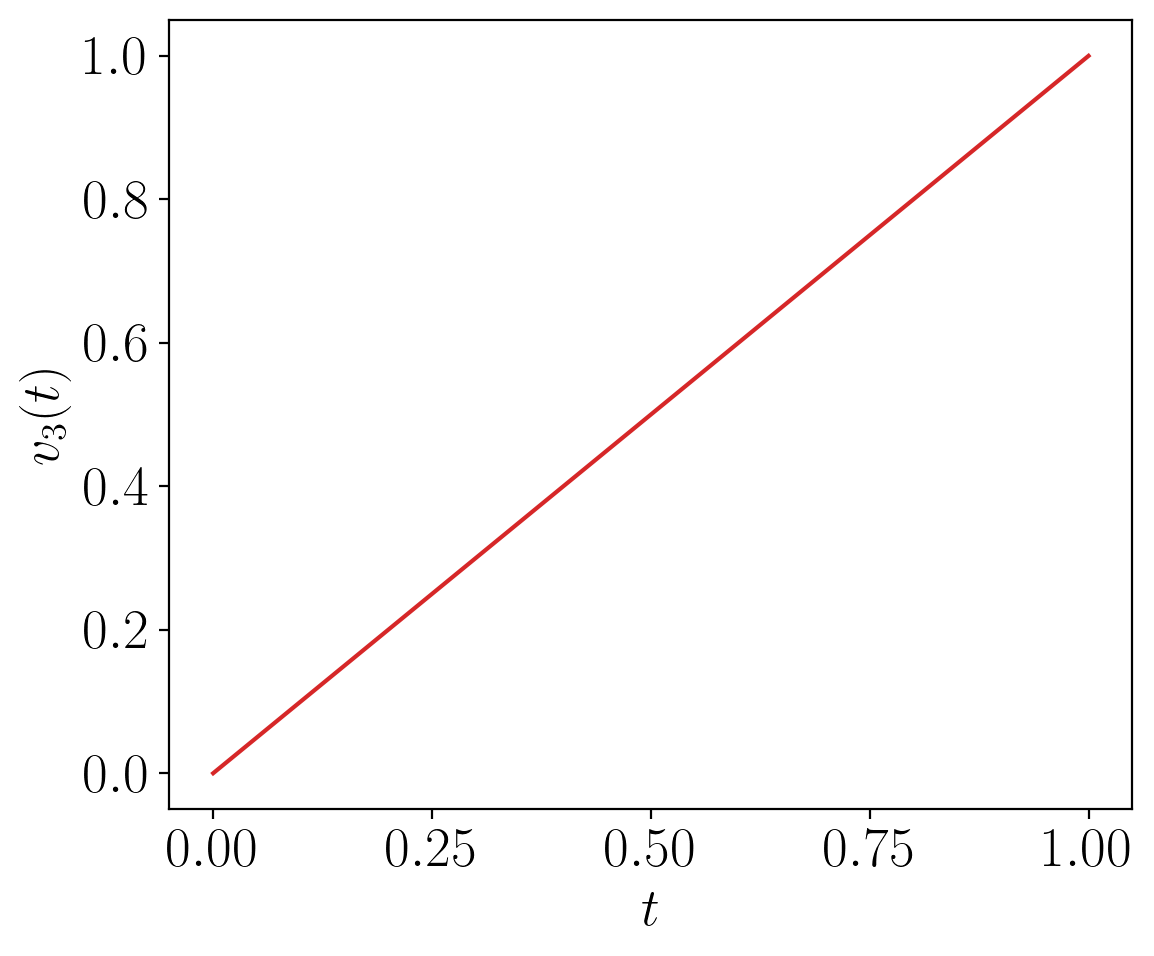

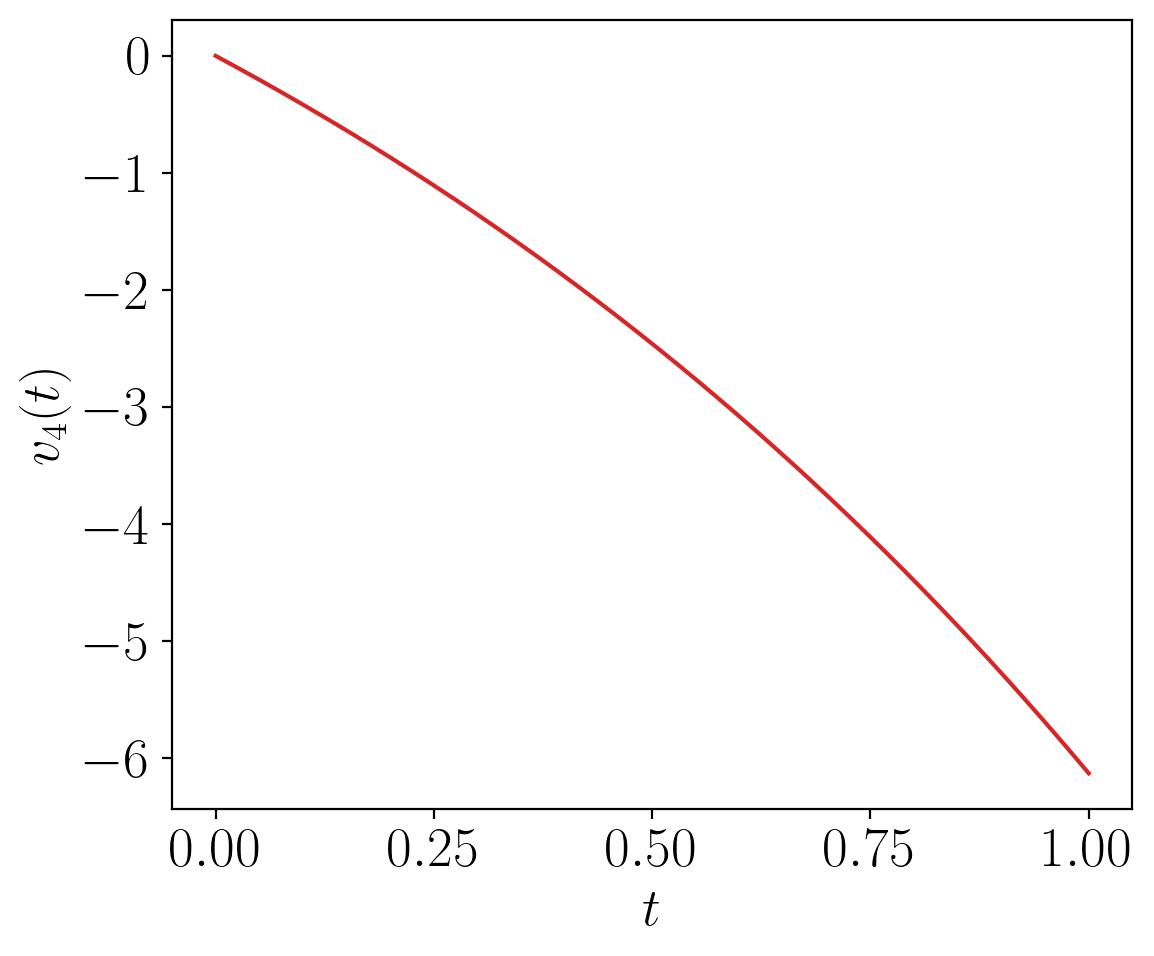

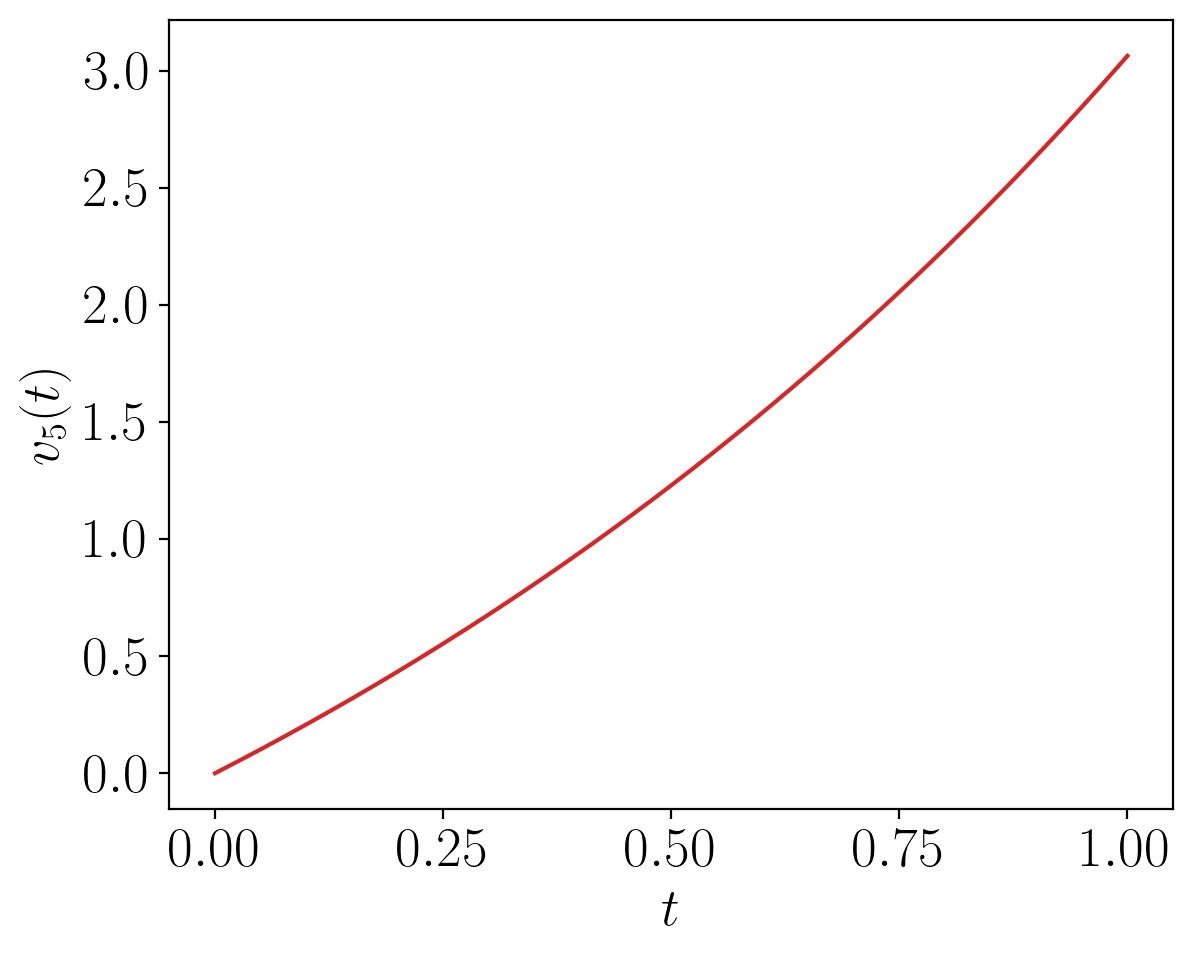

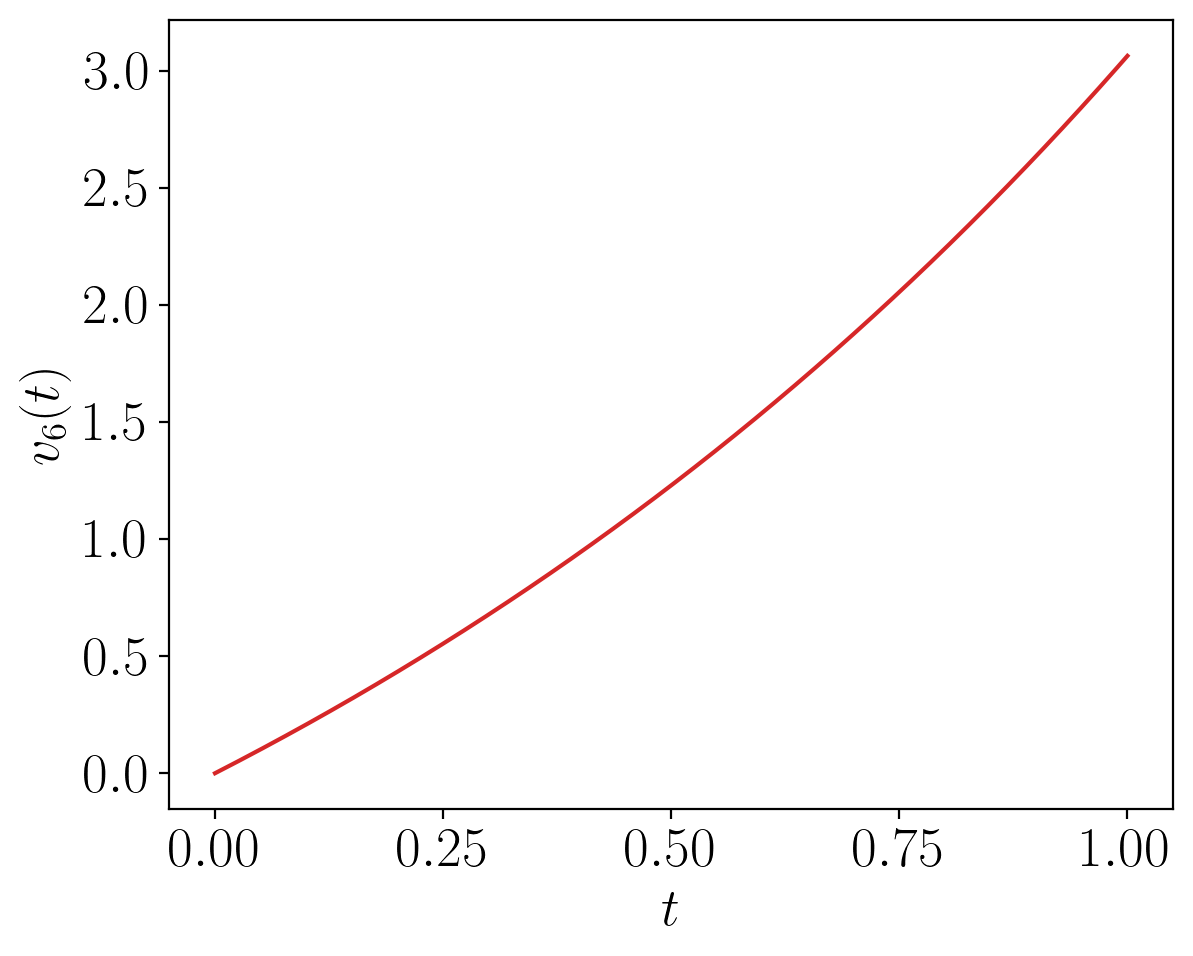

In [22]:
for i in range(6):
    fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))
    plt.plot(env.timesteps, vs[i,:], label=r'$v_1$', color ='tab:red')
    plt.xlabel(r'$t$', fontsize = fsL)
    plt.ylabel(fr'$v_{i+1}(t)$', fontsize = fsL)
    plt.tight_layout()
    plt.show()

In [27]:
def value_fct_vector(s,z):
    vs = env.solve_v123456()
    return vs[0] + vs[1] * z + vs[2] * s + vs[3] * s * z + vs[4] * z**2 + vs[5] * s**2

In [28]:
from scipy.interpolate import interp1d

In [38]:
def value_fct(t, s, z):
    values = value_fct_vector(s,z)
    return interp1d(env.timesteps, values)(t)

In [50]:
# Define the range of s and z
N = 100
s_values = np.linspace(80, 120, N)
z_values = np.linspace(80, 120, N)
S, Z = np.meshgrid(s_values, z_values)

T1 = np.zeros_like(S)
T2 = np.zeros_like(S)
T3 = np.zeros_like(S)

In [51]:
for i in range(N):
    for j in range(N):
        T1[i,j] = value_fct(0.1, S[i,j], Z[i,j])
        T2[i,j] = value_fct(0.5, S[i,j], Z[i,j])
        T3[i,j] = value_fct(0.9, S[i,j], Z[i,j])

In [59]:
min_value = min(0., T1.min(), T2.min(), T3.min()) 
max_value = max(T1.max(), T2.max(), T3.max()) 

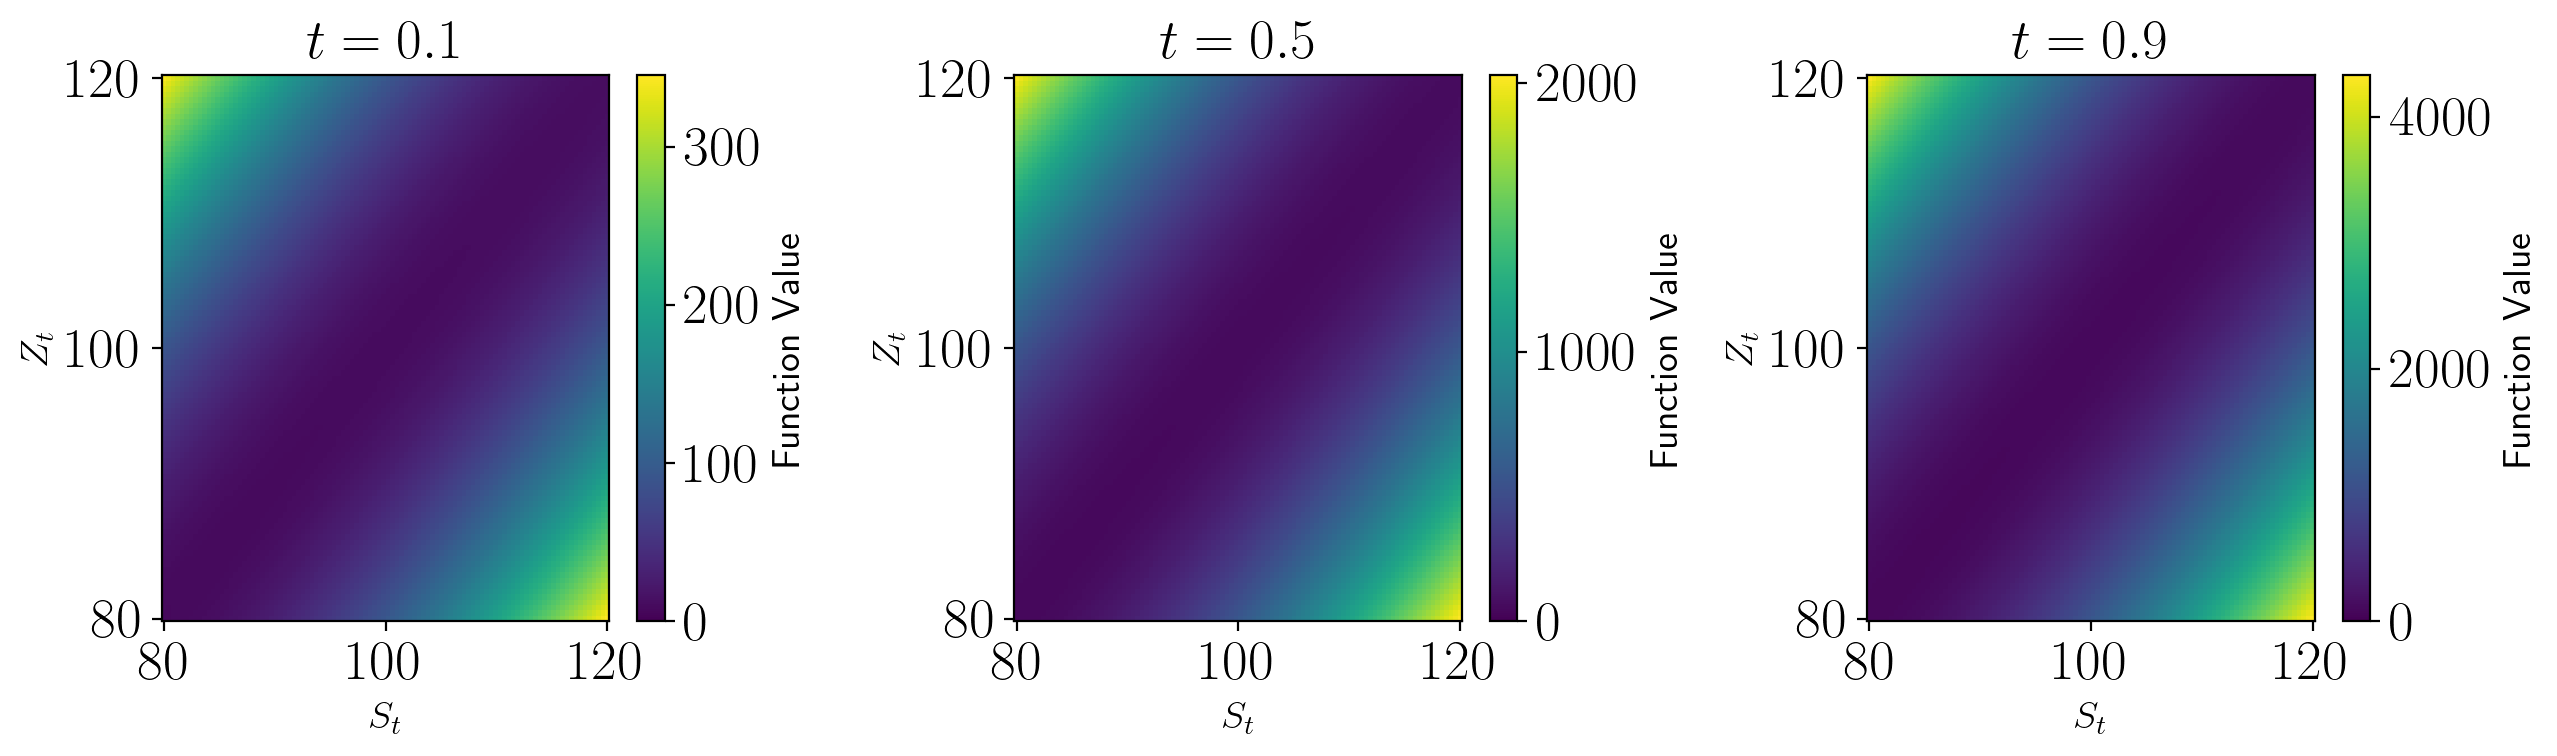

In [60]:
# Plot for t = 0.1
plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
c1 = plt.pcolormesh(S, Z, T1, shading='auto', cmap='viridis', vmin=min_value)#, vmax=max_value)
plt.colorbar(c1, label="Function Value")
plt.xlabel(r'$S_t$')
plt.ylabel(r'$Z_t$')
plt.title(r'$t = 0.1$')

# Plot for t = 0.5
plt.subplot(1, 3, 2)
c2 = plt.pcolormesh(S, Z, T2, shading='auto', cmap='viridis', vmin=min_value)#, vmax=max_value)
plt.colorbar(c2, label="Function Value")
plt.xlabel(r'$S_t$')
plt.ylabel(r'$Z_t$')
plt.title(r'$t = 0.5$')

# Plot for t = 0.9
plt.subplot(1, 3, 3)
c3 = plt.pcolormesh(S, Z, T3, shading='auto', cmap='viridis', vmin=min_value)#, vmax=max_value)
plt.colorbar(c3, label="Function Value")
plt.xlabel(r'$S_t$')
plt.ylabel(r'$Z_t$')
plt.title(r'$t = 0.9$')

plt.tight_layout()
plt.show()